=== ПОРІВНЯННЯ ПАРАМЕТРІВ (w) ===
1. Градієнтний спуск:  [4766729.24770638  821214.14349519  299983.57107964  695808.52272536]
2. Аналітичне рішення: [4766729.24770642  821214.14349519  299983.57107963  695808.52272538]
3. Scikit-learn:       [4766729.24770642  821214.14349519  299983.57107963  695808.52272537]

Максимальна розбіжність: 0.0000


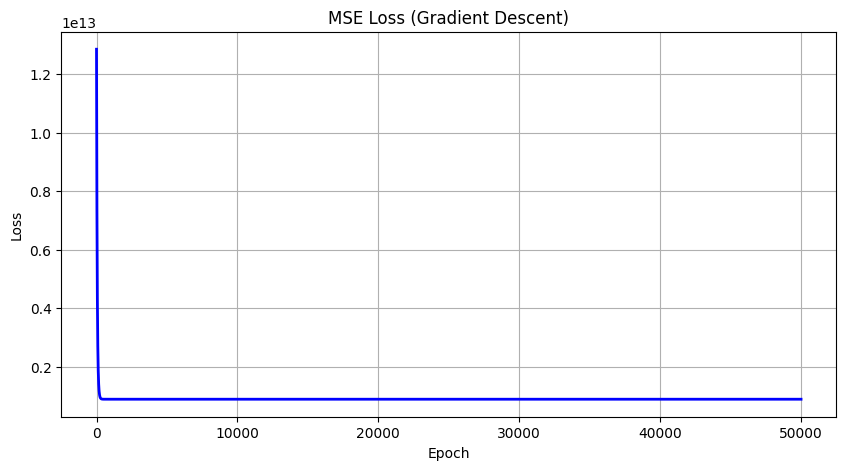

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def hypothesis(X, w):
    return X @ w

def mse_loss(X, y, w):
    m = len(y)
    return (1 / (2 * m)) * np.sum((hypothesis(X, w) - y) ** 2)

def gradient_step(X, y, w, lr):
    m = len(y)
    grad = (1 / m) * (X.T @ (hypothesis(X, w) - y))
    return w - lr * grad

def train_gd(X, y, lr=0.01, epochs=50000):
    w = np.zeros(X.shape[1])
    history = []
    for _ in range(epochs):
        w = gradient_step(X, y, w, lr)
        history.append(mse_loss(X, y, w))
    return w, history

def normal_equation(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

df = pd.read_csv('Housing.csv')

X_raw = df[['area', 'bedrooms', 'bathrooms']].values
y = df['price'].values

X_mean = np.mean(X_raw, axis=0)
X_std = np.std(X_raw, axis=0)
X_scaled = (X_raw - X_mean) / X_std

X_b = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])

w_gd, history = train_gd(X_b, y, lr=0.01, epochs=50000)
w_ne = normal_equation(X_b, y)

model = LinearRegression()
model.fit(X_scaled, y)
w_sklearn = np.hstack([model.intercept_, model.coef_])

print("=== ПОРІВНЯННЯ ПАРАМЕТРІВ (w) ===")
print(f"1. Градієнтний спуск:  {w_gd}")
print(f"2. Аналітичне рішення: {w_ne}")
print(f"3. Scikit-learn:       {w_sklearn}")
print(f"\nМаксимальна розбіжність: {np.max(np.abs(w_gd - w_sklearn)):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(history, color='blue', linewidth=2)
plt.title("MSE Loss (Gradient Descent)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()